## Import all Modules

In [14]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split


## Check if Cuda is Available


In [15]:
import torch

print(f'{torch.cuda.is_available() = }')
print(f'{torch.cuda.device_count() = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 2


In [16]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01


In [17]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


## Setting up the dataset paths

In [18]:
dataset_path='/kaggle/input/datasets/andrewmvd/car-plate-detection'

In [19]:
import re
def the_number_in_the_string(filename):
    match=re.search(r'\d+',filename)
    if match:
       return int(match.group(0))
    else: 
     return 0

In [20]:
print(the_number_in_the_string("file123.txt"))
print(the_number_in_the_string("no_numbers_here"))

123
0


## Data Preprocessing


In [21]:

# Initialize a dictionary to store labels and image information
labels_dict=dict(
    img_path=[],
    xmin=[],
    xmax=[],
    ymin=[],
    ymax=[],
    img_w=[],
    img_h=[]
)

xml_fiels=glob(f'{dataset_path}/annotations/*.xml')
for filename in sorted(xml_fiels,key=the_number_in_the_string):
    info=xet.parse(filename)
    root=info.getroot()
  # Find the 'object' element in the XML and extract bounding box information
    member_object=root.find('object')
    labels_info= member_object.find('bndbox')
    xmin=int(labels_info.find('xmin').text)
    xmax=int(labels_info.find('xmax').text)
    ymin=int(labels_info.find('ymin').text)
    ymax=int(labels_info.find('ymax').text)


    # Get the image filename and construct the full path to the image
    img_name=root.find('filename').text
    img_path=os.path.join(dataset_path,'images',img_name)

    
    # Append the extracted information
    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

    
    # Read the image to get its dimensions
    height, width, _ = cv2.imread(img_path).shape
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    
# Convert the dictionary to a pandas DataFrame
alldata=pd.DataFrame(labels_dict)

alldata
    

    




,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


## Dataset Splitting

In [22]:
train, test=train_test_split(alldata, test_size=0.1, random_state=42)
# 80% → train, 10% → validation, 10%->test
train, val=train_test_split(train, train_size=8/9, random_state=42)

print(f'''
len(train)={len(train)}
len(test)={len(test)}
len(val)={len(val)}
''')


len(train)=345
len(test)=44
len(val)=44



In [23]:
train

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
124,/kaggle/input/datasets/andrewmvd/car-plate-det...,305,320,256,267,400,267
315,/kaggle/input/datasets/andrewmvd/car-plate-det...,12,385,98,181,400,300
282,/kaggle/input/datasets/andrewmvd/car-plate-det...,37,319,145,203,350,263
236,/kaggle/input/datasets/andrewmvd/car-plate-det...,223,250,106,119,400,176
112,/kaggle/input/datasets/andrewmvd/car-plate-det...,49,164,135,191,240,400
...,...,...,...,...,...,...,...
110,/kaggle/input/datasets/andrewmvd/car-plate-det...,286,328,133,159,400,267
255,/kaggle/input/datasets/andrewmvd/car-plate-det...,116,273,156,188,400,267
292,/kaggle/input/datasets/andrewmvd/car-plate-det...,91,137,187,208,400,267
54,/kaggle/input/datasets/andrewmvd/car-plate-det...,148,257,61,118,400,300


## Creates a folder structure for a dataset split (train/val/test) in YOLO format.


In [24]:
def make_split_folder_in_yolo_format(split_name,split_df):
    labels_path=os.path.join('datasets', 'cars_license_plate_new', split_name, 'labels')
    images_path=os.path.join('datasets', 'cars_license_plate_new', split_name, 'images')


    # Create directories for labels and images
    os.makedirs(labels_path)
    os.makedirs(images_path)

    
    # Iterate over each row in the DataFrame
    for _,row in split_df.iterrows():
        img_name, img_extension=os.path.splitext(os.path.basename(row['img_path']))

     # Calculate YOLO format bond box coordints
        x_center = (row['xmin'] + row['xmax']) / 2 / row['img_w']
        y_center = (row['ymin'] + row['ymax']) / 2 / row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']

        
        # Save the label in YOLO format
        label_path=os.path.join(labels_path,f'{img_name}.txt')
        with open(label_path, 'w') as file:
            file.write(f"0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}\n")
        # Copy the image to the images directory
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))

    
    print(f"Created '{images_path}' and '{labels_path}'")

In [25]:
# Create YOLO format folders for train, validation, and test splits
make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)

Created 'datasets/cars_license_plate_new/train/images' and 'datasets/cars_license_plate_new/train/labels'
Created 'datasets/cars_license_plate_new/val/images' and 'datasets/cars_license_plate_new/val/labels'
Created 'datasets/cars_license_plate_new/test/images' and 'datasets/cars_license_plate_new/test/labels'


In [26]:
os.getcwd()

'/kaggle/working'

In [27]:

for root, dirs, files in os.walk('datasets'):
    print(root)

datasets
datasets/cars_license_plate_new
datasets/cars_license_plate_new/test
datasets/cars_license_plate_new/test/images
datasets/cars_license_plate_new/test/labels
datasets/cars_license_plate_new/val
datasets/cars_license_plate_new/val/images
datasets/cars_license_plate_new/val/labels
datasets/cars_license_plate_new/train
datasets/cars_license_plate_new/train/images
datasets/cars_license_plate_new/train/labels


In [28]:
datasets_yaml='''
path: cars_license_plate_new

train: train/images
test: test/images
val: val/images

nc: 1

names: ['license_plate']
'''

with open('datasets.yaml','w') as file:
    file.write(datasets_yaml)

In [29]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [30]:
model.train(
    data='datasets.yaml',  
    epochs=100,            
    batch=16,          
    device='cuda',         
    imgsz=320,            
    cache=True            
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e8fb07d23c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Model Performance Evaluation and Accuracy Visualization

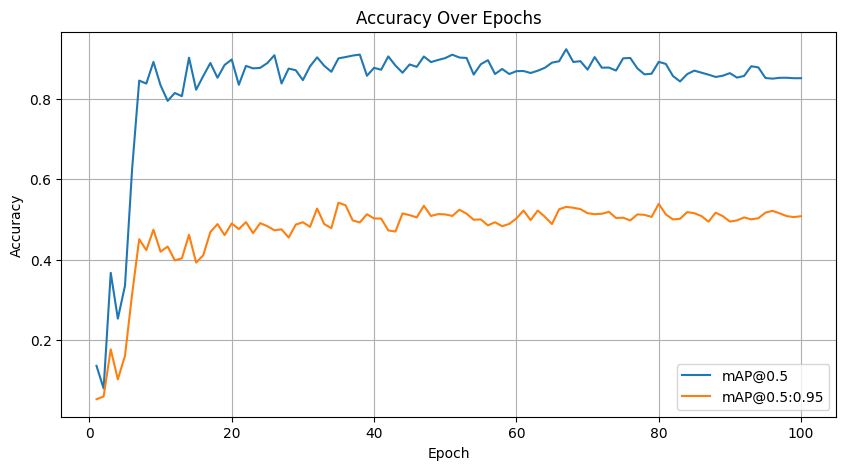

In [32]:
log_dir=max(glob('runs/detect/train*'), key=the_number_in_the_string)

results=pd.read_csv(os.path.join(log_dir, 'results.csv'))

results.columns=results.columns.str.strip()

results.columns

# Extract epochs and accuracy metrics
epochs=results.index+1
mAP_0_5 = results['metrics/mAP50(B)']  
mAP_0_5_0_95 = results['metrics/mAP50-95(B)']  

# Plot the accuracy over epochs
plt.figure(figsize=(10,5))
plt.plot(epochs, mAP_0_5, label='mAP@0.5')
plt.plot(epochs, mAP_0_5_0_95, label='mAP@0.5:0.95')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
model.save('best_license_plate_model.pt')

## License Plate Detection and OCR Recognition

In [34]:
!pip3 install pytesseract

In [35]:
import pytesseract
from pytesseract import Output

def predict_and_plot(path_test_car):
    
    # Perform prediction on the test image using the model
    results = model.predict(path_test_car, device='cpu')

    # Load the image using OpenCV
    image = cv2.imread(path_test_car)
    # Convert the image from BGR (OpenCV default) to RGB (matplotlib default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Extract the bounding boxes and labels from the results
    for result in results:
        for box in result.boxes:
            # Get the coordinates of the bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
         
            confidence = box.conf[0]

            # Draw the bounding box on the image
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Draw the confidence score near the bounding box
            cv2.putText(image, f'{confidence*100:.2f}%', (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

            # Crop the bounding box from the image for OCR
            roi = image[y1:y2, x1:x2]

         
            text = pytesseract.image_to_string(roi, config='--psm 6')
            print(f"Detected text: {text}")


    plt.imshow(image)
    plt.axis('off')  
    plt.show()  


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars425.png: 160x320 1 license_plate, 56.8ms
Speed: 1.0ms preprocess, 56.8ms inference, 22.1ms postprocess per image at shape (1, 3, 160, 320)
Detected text: G526 JHD |



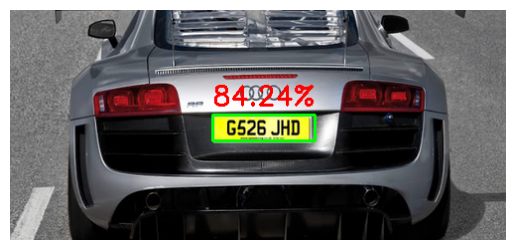

In [36]:
predict_and_plot(test.iloc[0].img_path)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars181.png: 320x192 1 license_plate, 53.9ms
Speed: 1.0ms preprocess, 53.9ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 192)
Detected text: | JHTHAD



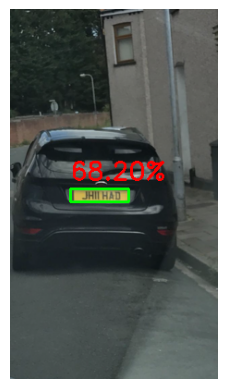

In [37]:
predict_and_plot(test.iloc[2].img_path)